# Random Forest Model

This notebook reuses the same preprocessing logic from `preprocessing.ipynb`, we will use a random forest classifier for our credit risk detection project.


## Why Random Forests

Random forests are a good fit for this problem because they combine many decision trees and average their predictions. That usually makes them more stable than a single tree while still allowing them to learn non linear patterns and interactions between borrower features.

For credit risk data, that is useful because default behavior may depend on combinations of income, loan amount, interest rate, prior credit history, etc. Random forests can capture those relationships without requiring a fully linear assumption.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


In [2]:
# Load the dataset
df = pd.read_csv("data/credit_risk_dataset.csv")
df = df.drop_duplicates().copy()

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (32416, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (25932, 11)
Test shape: (6484, 11)


In [4]:
# Reusing the same data cleaning logic from preprocessing.ipynb
def clean_invalid_rows(df):
    df = df.copy()
    df = df[(df["person_age"] > 0) & (df["person_age"] < 100)]
    df = df[df["person_income"] > 0]
    df = df[df["loan_amnt"] > 0]
    df = df[
        (df["person_emp_length"].isna())
        | ((df["person_emp_length"] >= 0) & (df["person_emp_length"] <= 50))
    ]
    df = df[
        (df["person_emp_length"].isna())
        | (df["person_emp_length"] <= df["person_age"])
    ]
    df = df[(df["loan_int_rate"].isna()) | (df["loan_int_rate"] > 0)]
    return df


X_train = clean_invalid_rows(X_train)
y_train = y_train.loc[X_train.index]

X_test = clean_invalid_rows(X_test)
y_test = y_test.loc[X_test.index]

print("Cleaned train shape:", X_train.shape)
print("Cleaned test shape:", X_test.shape)


Cleaned train shape: (25925, 11)
Cleaned test shape: (6484, 11)


In [5]:
# Reusing the same engineered features from preprocessing.ipynb
def add_engineered_features(df):
    df = df.copy()
    df["income_to_loan_ratio"] = df["person_income"] / df["loan_amnt"]
    df["emp_length_to_age_ratio"] = df["person_emp_length"] / df["person_age"]
    return df


X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

display(X_train.head())


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan_ratio,emp_length_to_age_ratio
7173,23,75800,RENT,0.0,PERSONAL,A,7000,6.54,0.09,N,2,10.828571,0.000000
16396,25,61959,RENT,9.0,EDUCATION,C,25000,12.73,0.40,Y,4,2.478360,0.360000
21744,31,53088,RENT,0.0,PERSONAL,A,6000,6.54,0.11,N,9,8.848000,0.000000
27805,27,228000,MORTGAGE,12.0,HOMEIMPROVEMENT,A,6000,7.14,0.03,N,6,38.000000,0.444444
24563,29,54000,RENT,0.0,PERSONAL,D,10000,14.96,0.19,N,9,5.400000,0.000000


In [6]:
# Reusing the same preprocessing pipeline from preprocessing.ipynb
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

log_features = ["person_income", "loan_amnt", "income_to_loan_ratio"]

numeric_features = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "emp_length_to_age_ratio"
]

log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("log_num", log_transformer, log_features),
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (25925, 28)
Processed test shape: (6484, 28)


## Fine tune random forest

We test a small grid of hyperparameters and select the model with the best cross-validated ROC-AUC score. ROC-AUC is useful here because it measures how well the model ranks defaulters above non defaulters across thresholds. We will be making use of GridSearch for this fine tuning process.
 
In our grid search we will optimise for the following hyperparameters:
- The number of trees in the forest
- The maximum depth of each tree
- The minimum number of samples required to split the node
- The minimum number of samples that must be in a leaf node

We will use 3 fold cross validation 


In [7]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1
)

param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [None, 12],
    "min_samples_split": [2],
    "min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_processed, y_train)

tuning_results = pd.DataFrame(grid_search.cv_results_)[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

display(tuning_results.head(10))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_train_score,mean_test_score,rank_test_score
1,300,None,2,1,1.000000,0.932089,1
0,150,None,2,1,1.000000,0.931278,2
5,300,12,2,1,0.983186,0.931220,3
4,150,12,2,1,0.982487,0.930922,4
3,300,None,2,5,0.995320,0.928773,5
6,150,12,2,5,0.970099,0.928489,6
7,300,12,2,5,0.970499,0.928458,7
2,150,None,2,5,0.995132,0.928215,8


In [8]:
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("Best parameters:", best_params)
print("Best cross-validated ROC-AUC:", round(best_cv_score, 4))


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validated ROC-AUC: 0.9321


## Fit the final random forest model

We now use the best hyperparameters from the search and evaluate the final model on both training and test data.


In [9]:
final_rf = grid_search.best_estimator_

y_train_pred = final_rf.predict(X_train_processed)
y_test_pred = final_rf.predict(X_test_processed)

y_train_proba = final_rf.predict_proba(X_train_processed)[:, 1]
y_test_proba = final_rf.predict_proba(X_test_processed)[:, 1]


In [20]:
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Test Precision:", round(precision_score(y_test, y_test_pred), 4))
print("Test Recall:", round(recall_score(y_test, y_test_pred), 4))
print("Test F1 Score:", round(f1_score(y_test, y_test_pred), 4))
print("Train ROC-AUC:", round(roc_auc_score(y_train, y_train_proba), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_test_proba), 4))


Train Accuracy: 1.0
Test Accuracy: 0.9332
Test Precision: 0.9768
Test Recall: 0.7116
Test F1 Score: 0.8233
Train ROC-AUC: 1.0
Test ROC-AUC: 0.9318


In [11]:
evaluation_summary = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    "value": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba)
    ]
})

display(evaluation_summary)


,metric,value
0,accuracy,0.933220
1,precision,0.976767
2,recall,0.711566
3,f1_score,0.823337
4,roc_auc,0.931846


In [12]:
# Look at a few example predictions
prediction_examples = X_test.copy().reset_index(drop=True)
prediction_examples["actual_default"] = y_test.reset_index(drop=True)
prediction_examples["predicted_default_probability"] = y_test_proba
prediction_examples["predicted_class"] = y_test_pred

display(
    prediction_examples[
        [
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "loan_percent_income",
            "loan_grade",
            "actual_default",
            "predicted_default_probability",
            "predicted_class"
        ]
    ].head(15)
)


,person_income,loan_amnt,loan_int_rate,loan_percent_income,loan_grade,actual_default,predicted_default_probability,predicted_class
0,56461,5400,15.68,0.10,E,0,0.450000,0
1,108000,4925,NaN,0.05,B,1,0.080000,0
2,102000,18000,9.33,0.18,B,0,0.010000,0
3,45000,10000,12.42,0.22,B,0,0.043333,0
4,30000,12000,10.39,0.40,B,1,0.996667,1
5,113000,9600,NaN,0.08,C,0,0.090000,0
6,73000,16000,19.41,0.22,F,1,0.890000,1
7,90000,7500,15.58,0.08,D,0,0.123333,0
8,135000,24250,12.87,0.18,C,0,0.053333,0
9,52000,8000,7.51,0.15,A,0,0.026667,0


## Interpret the model feature importances

Random forests does not give coefficients like in logistic regression, however it does estimate feature importance based on how much each feature helps reduce impurity across the trees. We should take a look at the top features with the most importance. Then we should also plot this into a graph to create a nice visual


In [13]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


,feature,importance
2,log_num__income_to_loan_ratio,0.144607
0,log_num__person_income,0.123540
5,num__loan_int_rate,0.120012
6,num__loan_percent_income,0.117675
1,log_num__loan_amnt,0.061319
22,cat__loan_grade_D,0.052768
8,num__emp_length_to_age_ratio,0.047437
3,num__person_age,0.037943
12,cat__person_home_ownership_RENT,0.037936
4,num__person_emp_length,0.034966


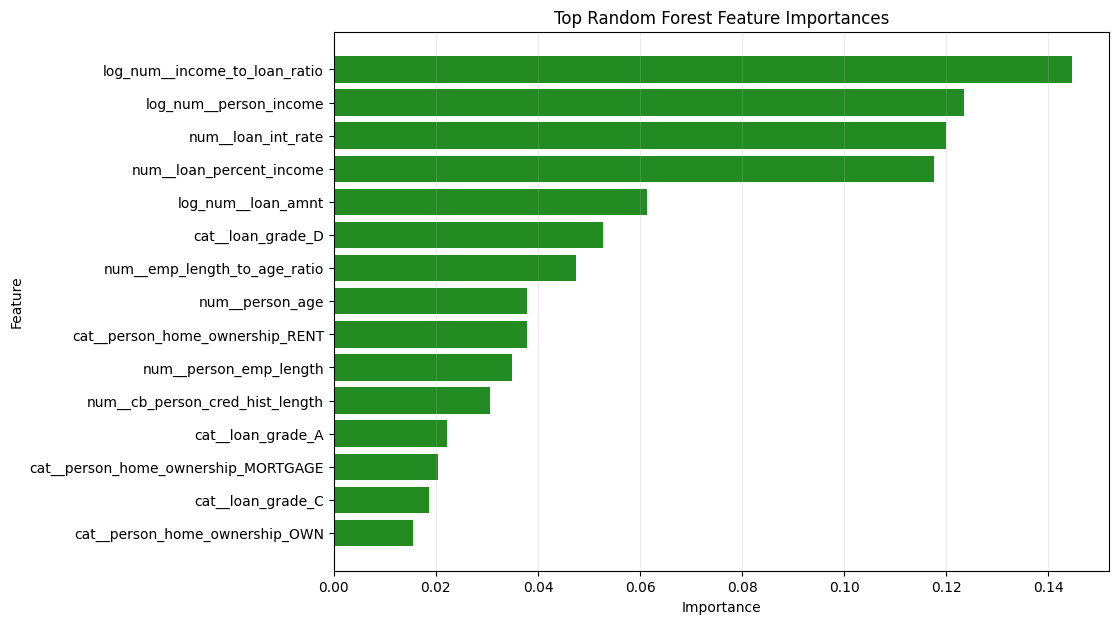

In [14]:
plot_df = feature_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance"], color="forestgreen")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.25)
plt.show()


## Extra Evaluation Plots

These plots help us see how well the predicted probabilities separate defaulting borrowers from non defaulting borrowers. This graph will give us a nice visualization for each prediciton how many borrowers defaulted or non defaulted. Ideally we should see that all the probablities close to 0 should be non defaulted and all the probabilities close to 1 should be defaulted.


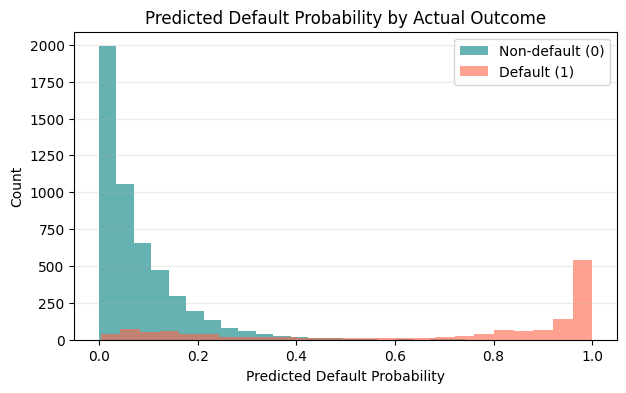

In [15]:
plt.figure(figsize=(7, 4))
plt.hist(
    y_test_proba[y_test.to_numpy() == 0],
    bins=25,
    alpha=0.6,
    label="Non-default (0)",
    color="teal"
)
plt.hist(
    y_test_proba[y_test.to_numpy() == 1],
    bins=25,
    alpha=0.6,
    label="Default (1)",
    color="tomato"
)
plt.title("Predicted Default Probability by Actual Outcome")
plt.xlabel("Predicted Default Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## What the scores mean & What we learned

- **Accuracy** tells us the share of all predictions that were correct.
- **Precision** tells us, out of the loans predicted to default, how many actually defaulted.
- **Recall** tells us, out of the loans that actually defaulted, how many the model successfully caught.
- **F1 score** balances precision and recall into one number.
- **ROC-AUC** tells us how well the model ranks risky borrowers ahead of safer borrowers across thresholds. Higher is better.

Also when you look at the graph above we can see that all the predicitions that predicted a high default rate were correct. So our model is very good at catching customers who will default. For non default we can see that the model is most very accuarte but there are a few mistakes when prediciting low probability of defaulting but the user actuallyt defaulted. Overall the shape of the graph is as we expected also we can see once again that our data is skewed towards non defaults.

Overall Random Forest has done a great job.